# Student Performance Prediction using Machine Learning

## Internship Project

### Domain:
Machine Learning

### Objective:
To predict students' mathematics scores using various demographic and educational factors. Multiple regression models are trained and compared to identify the best-performing model.

### Algorithms Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- AdaBoost Regressor
- XGBoost Regressor

## 1. Import Libraries

In [280]:
# Import Libraries

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Save and Load Models
import pickle

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset

In [281]:
df = pd.read_csv("../data/StudentsPerformance.csv")

print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Data Understanding

In [282]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (1000, 8)

Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data Types:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


In [283]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [284]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [285]:
df.describe(include="object").T

,count,unique,top,freq
gender,1000,2,female,518
race/ethnicity,1000,5,group C,319
parental level of education,1000,6,some college,226
lunch,1000,2,standard,645
test preparation course,1000,2,none,642


In [286]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows: 0


## 4. Exploratory Data Analysis (EDA)

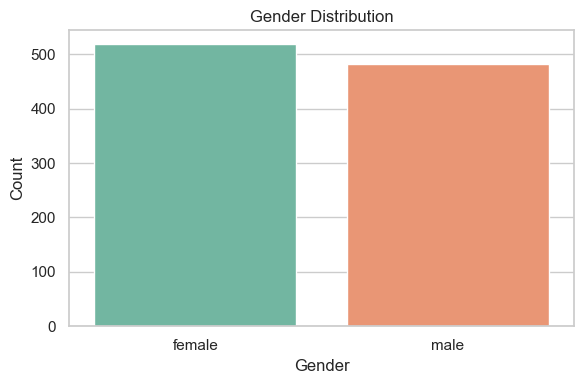

In [287]:
# Graph 1: Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="gender", palette="Set2")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../graphs/01_gender_distribution.png", dpi=300)

plt.show()
plt.close()

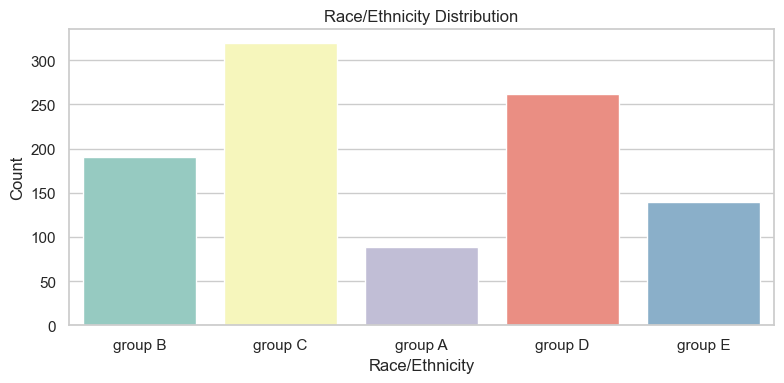

In [288]:
# Graph 2: Race/Ethnicity Distribution

plt.figure(figsize=(8,4))

sns.countplot(data=df, x="race/ethnicity", palette="Set3")

plt.title("Race/Ethnicity Distribution")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../graphs/02_race_ethnicity_distribution.png", dpi=300)

plt.show()
plt.close()

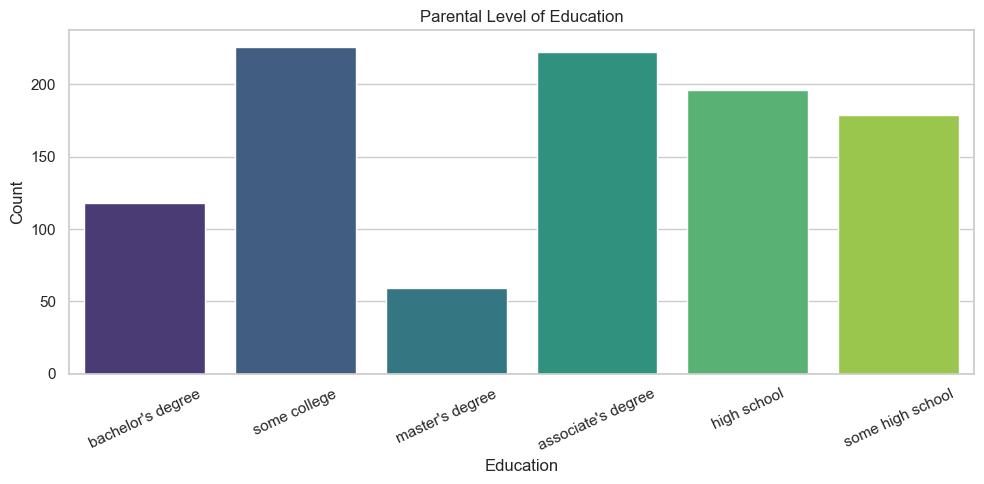

In [289]:
# Graph 3: Parental Education Distribution

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="parental level of education",
    palette="viridis"
)

plt.xticks(rotation=25)

plt.title("Parental Level of Education")
plt.xlabel("Education")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../graphs/03_parental_education_distribution.png", dpi=300)

plt.show()
plt.close()

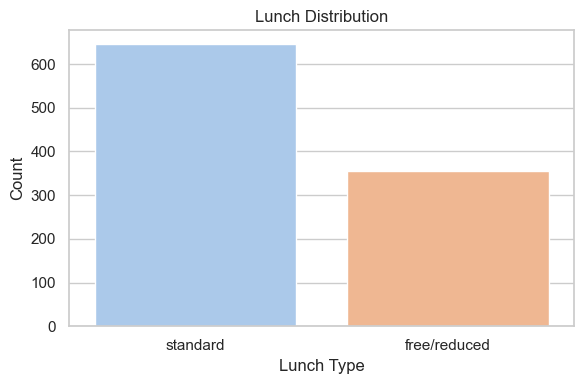

In [290]:
# Graph 4: Lunch Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="lunch", palette="pastel")

plt.title("Lunch Distribution")
plt.xlabel("Lunch Type")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../graphs/04_lunch_distribution.png", dpi=300)

plt.show()
plt.close()

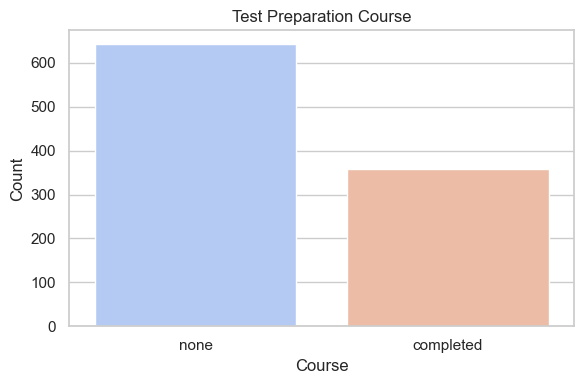

In [291]:
# Graph 5: Test Preparation Course

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="test preparation course",
    palette="coolwarm"
)

plt.title("Test Preparation Course")
plt.xlabel("Course")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../graphs/05_test_preparation_distribution.png", dpi=300)

plt.show()
plt.close()

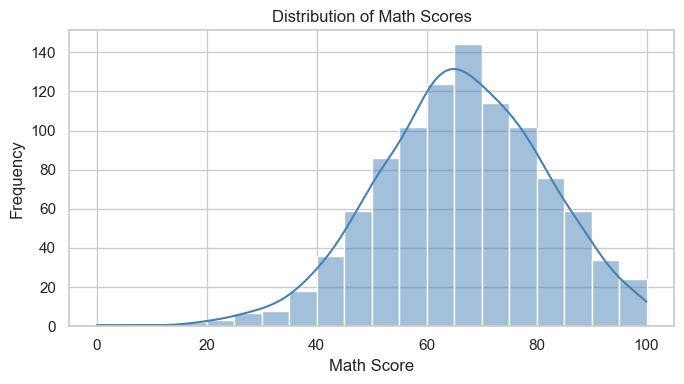

In [292]:
# Graph 6: Math Score Distribution

plt.figure(figsize=(7,4))

sns.histplot(df["math score"], bins=20, kde=True, color="steelblue")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../graphs/06_math_score_distribution.png", dpi=300)

plt.show()
plt.close()

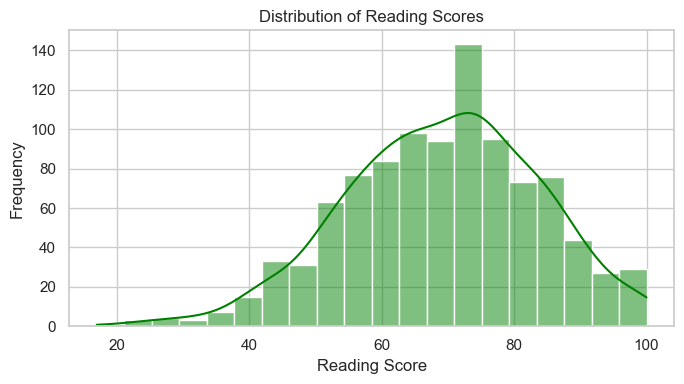

In [293]:
# Graph 7: Reading Score Distribution

plt.figure(figsize=(7,4))

sns.histplot(df["reading score"], bins=20, kde=True, color="green")

plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../graphs/07_reading_score_distribution.png", dpi=300)

plt.show()
plt.close()

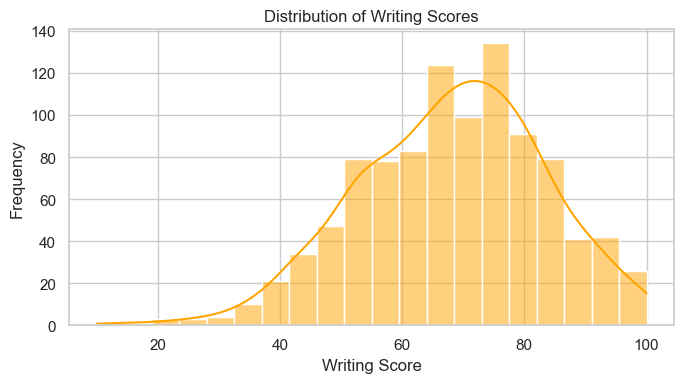

In [294]:
# Graph 8: Writing Score Distribution

plt.figure(figsize=(7,4))

sns.histplot(df["writing score"], bins=20, kde=True, color="orange")

plt.title("Distribution of Writing Scores")
plt.xlabel("Writing Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../graphs/08_writing_score_distribution.png", dpi=300)

plt.show()
plt.close()

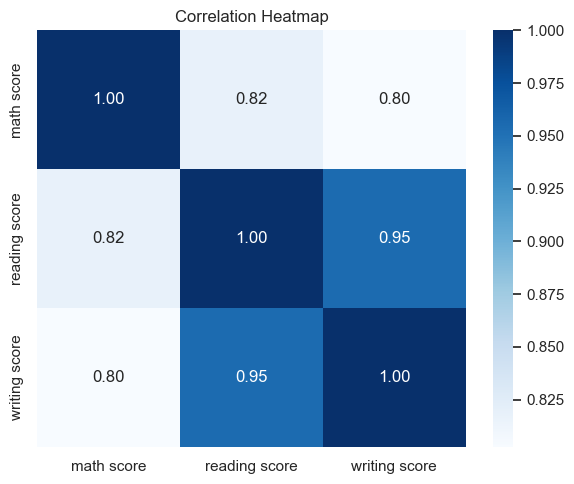

In [295]:
# Graph 9: Correlation Heatmap

plt.figure(figsize=(6,5))

corr = df[["math score","reading score","writing score"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../graphs/09_correlation_heatmap.png", dpi=300)

plt.show()
plt.close()

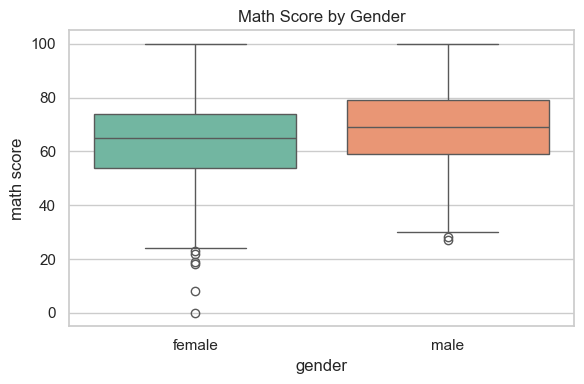

In [296]:
# Graph 10: Math Score by Gender

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="gender",
    y="math score",
    palette="Set2"
)

plt.title("Math Score by Gender")

plt.tight_layout()
plt.savefig("../graphs/10_math_score_by_gender.png", dpi=300)

plt.show()
plt.close()

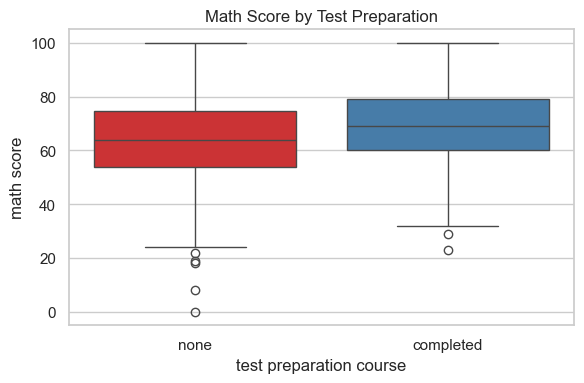

In [297]:
# Graph 11: Math Score by Test Preparation

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="math score",
    palette="Set1"
)

plt.title("Math Score by Test Preparation")

plt.tight_layout()
plt.savefig("../graphs/11_math_score_by_test_preparation.png", dpi=300)

plt.show()
plt.close()

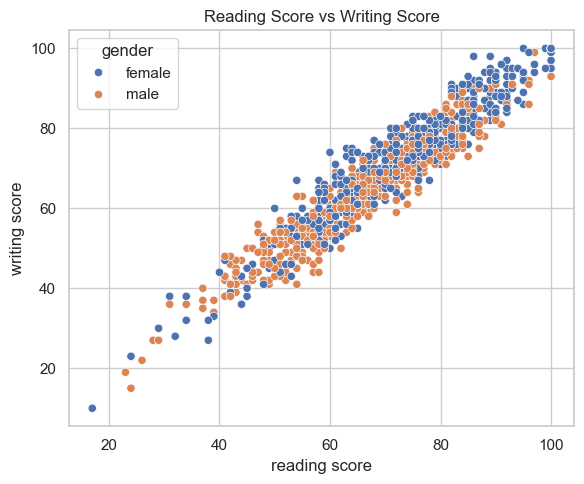

In [298]:
# Graph 12: Reading Score vs Writing Score

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x="reading score",
    y="writing score",
    hue="gender"
)

plt.title("Reading Score vs Writing Score")

plt.tight_layout()
plt.savefig("../graphs/12_reading_vs_writing_score.png", dpi=300)

plt.show()
plt.close()

## 5. Data Preprocessing

In [299]:
# Features and Target

X = df.drop(columns=["math score"])
y = df["math score"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1000, 7)
Target Shape : (1000,)


In [300]:
# Categorical and Numerical Columns

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

Numerical Columns:
['reading score', 'writing score']


In [301]:
# One-Hot Encoding

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [302]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (800, 7)
Testing Set : (200, 7)


In [303]:
# Training and Testing Samples

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 800
Testing Samples : 200


## 6. Model Training

In [304]:
# Regression Models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

print(models.keys())

dict_keys(['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost'])


In [305]:
# Train Models

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
AdaBoost trained successfully.


## 7. Model Evaluation

In [306]:
# Evaluate Models

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "MSE": round(mse, 3),
        "RMSE": round(rmse, 3),
        "R2 Score": round(r2, 4)
    })

In [307]:
# Results DataFrame

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.215,29.095,5.394,0.8804
1,Gradient Boosting,4.303,31.064,5.574,0.8723
2,Random Forest,4.666,36.311,6.026,0.8508
3,AdaBoost,4.717,36.358,6.030,0.8506
4,Decision Tree,6.240,60.520,7.779,0.7513


In [308]:
# Best Model

best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model : {best_model_name}")

Best Model : Linear Regression


In [309]:
# Best Model Object

best_model = trained_models[best_model_name]

## 8. Model Comparison

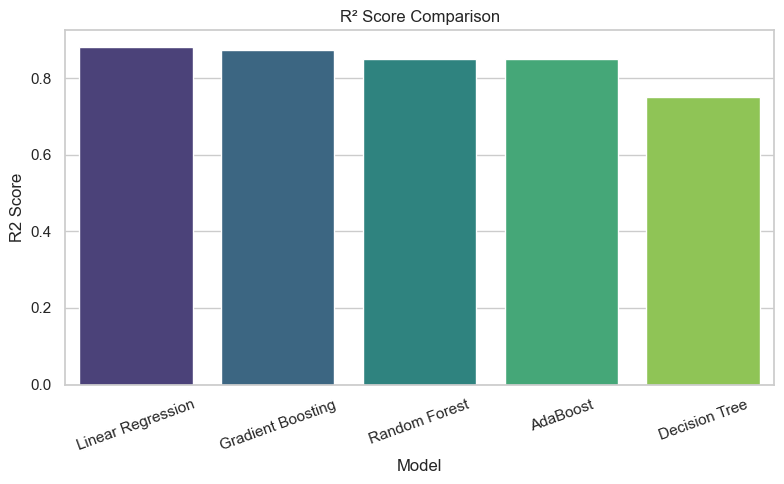

In [310]:
# R² Score Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    palette="viridis"
)

plt.title("R² Score Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../graphs/13_r2_score_comparison.png", dpi=300)

plt.show()
plt.close()

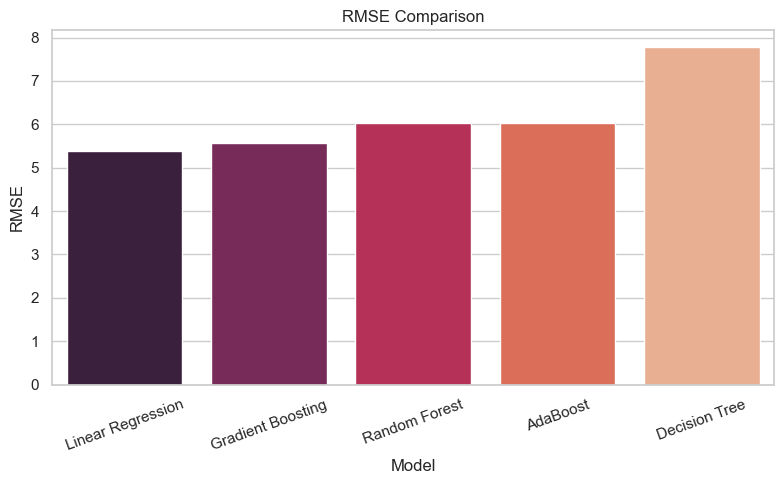

In [311]:
# RMSE Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    palette="rocket"
)

plt.title("RMSE Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../graphs/14_rmse_comparison.png", dpi=300)

plt.show()
plt.close()

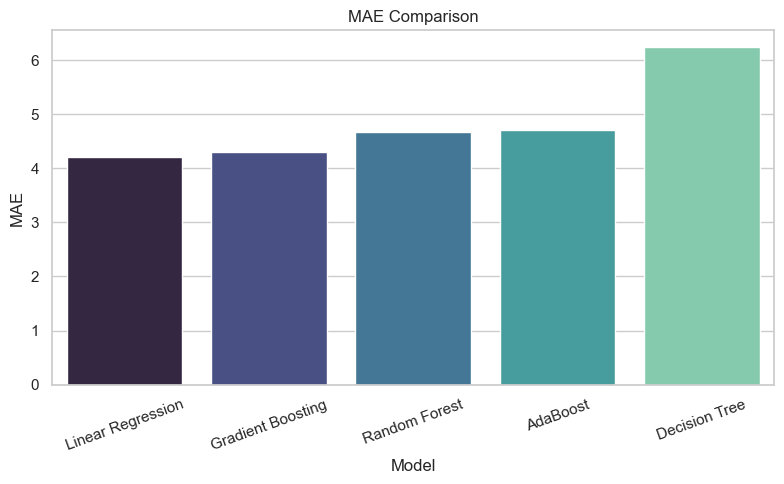

In [312]:
# MAE Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    palette="mako"
)

plt.title("MAE Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../graphs/15_mae_comparison.png", dpi=300)

plt.show()
plt.close()

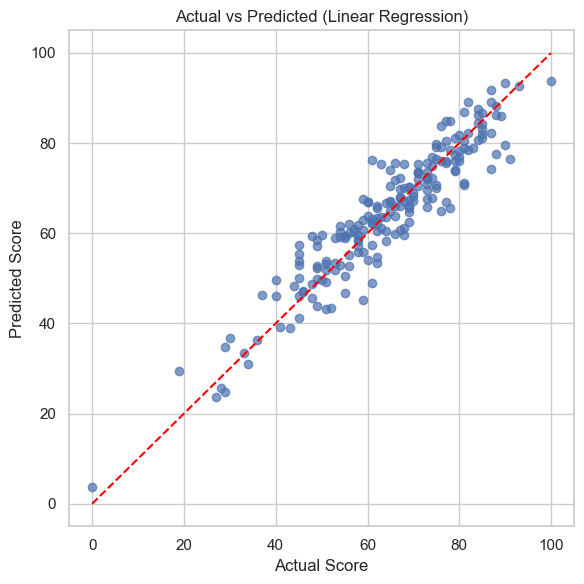

In [313]:
# Actual vs Predicted

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title(f"Actual vs Predicted ({best_model_name})")

plt.tight_layout()
plt.savefig("../graphs/16_actual_vs_predicted.png", dpi=300)

plt.show()
plt.close()

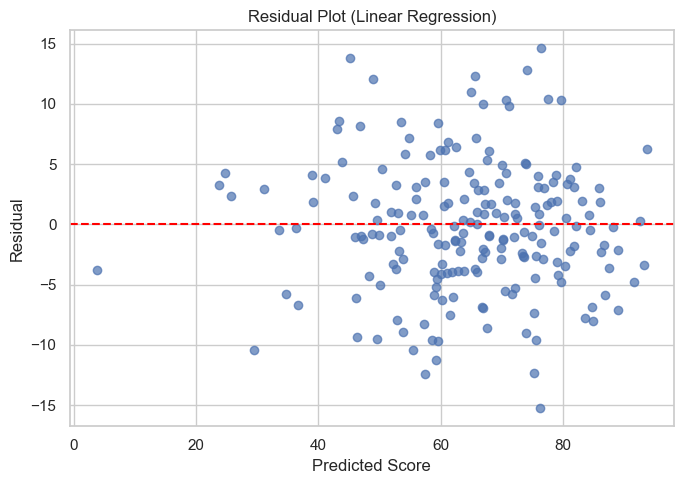

In [314]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title(f"Residual Plot ({best_model_name})")

plt.tight_layout()
plt.savefig("../graphs/17_residual_plot.png", dpi=300)

plt.show()
plt.close()

In [315]:
# Feature Importance

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "AdaBoost"
]

if best_model_name in tree_models:

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

    importance = best_model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(10)

    plt.figure(figsize=(9,5))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        palette="crest"
    )

    plt.title(f"Feature Importance ({best_model_name})")

    plt.tight_layout()
    plt.savefig("../graphs/18_feature_importance.png", dpi=300)

    plt.show()
    plt.close()

else:

    print("Feature Importance is not available for Linear Regression.")

Feature Importance is not available for Linear Regression.


## 9. Best Model Selection

In [316]:
print("Model Performance")

display(results_df)

print(f"\nBest Model: {best_model_name}")

print(f"R² Score : {results_df.iloc[0]['R2 Score']}")
print(f"RMSE      : {results_df.iloc[0]['RMSE']}")
print(f"MAE       : {results_df.iloc[0]['MAE']}")

Model Performance


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.215,29.095,5.394,0.8804
1,Gradient Boosting,4.303,31.064,5.574,0.8723
2,Random Forest,4.666,36.311,6.026,0.8508
3,AdaBoost,4.717,36.358,6.030,0.8506
4,Decision Tree,6.240,60.520,7.779,0.7513



Best Model: Linear Regression
R² Score : 0.8804
RMSE      : 5.394
MAE       : 4.215


## 10. Save the Model

In [317]:
with open("../models/best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved successfully!")

Best model saved successfully!


## Conclusion

In [318]:
print("**SUMMARY**")

print(f"Dataset Size      : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Models Trained    : {len(models)}")
print(f"Best Model        : {best_model_name}")
print(f"Results DataFrame :")
display(results_df)
print(f"Best R² Score     : {results_df.iloc[0]['R2 Score']}")
print(f"Best RMSE         : {results_df.iloc[0]['RMSE']}")
print(f"Best MAE          : {results_df.iloc[0]['MAE']}")

**SUMMARY**
Dataset Size      : 1000 rows × 8 columns
Models Trained    : 5
Best Model        : Linear Regression
Results DataFrame :


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.215,29.095,5.394,0.8804
1,Gradient Boosting,4.303,31.064,5.574,0.8723
2,Random Forest,4.666,36.311,6.026,0.8508
3,AdaBoost,4.717,36.358,6.030,0.8506
4,Decision Tree,6.240,60.520,7.779,0.7513


Best R² Score     : 0.8804
Best RMSE         : 5.394
Best MAE          : 4.215
